<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/elliptic-pde/dtb_elliptic_two_frequency_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTB--Ritz two-frequency Poisson experiment

On $[-1,1]^2$,
$$u_*=\cos(\pi x/2)\cos(\pi y/2)+0.1\cos(7\pi x/2)\cos(5\pi y/2).$$
The high-frequency component is small in amplitude but expensive in the energy norm. Snapshots use outer iteration as diagnostic time and place the exact reference above DTB.

In [7]:
# Repository setup for a fresh Colab runtime.
import os, subprocess
from pathlib import Path
if Path('DTB_elliptic_utils.py').exists(): ROOT = Path.cwd()
else:
    ROOT = Path('/content/dtb-colab-experiments')
    if not ROOT.exists(): subprocess.run(['git','clone','-b','elliptic-pde','https://github.com/sun-mengwei/dtb-colab-experiments.git',str(ROOT)], check=True)
    os.chdir(ROOT)
print('repository:', ROOT)

repository: /content/dtb-colab-experiments


In [8]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
from DTB_elliptic_utils import (MLP, armijo_update, direct_ritz_energy, envelope_gradient, expand_direction, flatten_parameters, make_box_trial, matrix_ritz_energy, predict_tangent, relative_l2_error, sample_box, select_parameter_indices, solve_tangent_ritz, summarize_history)

torch.set_default_dtype(torch.float64); torch.manual_seed(2)
DIM, VOLUME = 2, 4.0
N_TRAIN, N_VALID = 2000, 4096
OUTER_STEPS, TANGENT_DIM = 40, 128
RIDGE_RELATIVE, INITIAL_STEP = 1e-4, 1.0
model = MLP(DIM, width=20, depth=2)
theta, spec = flatten_parameters(model)
trial = make_box_trial(model, spec)
indices = select_parameter_indices(theta.numel(), TANGENT_DIM, seed=12)
x_train, x_valid = sample_box(N_TRAIN, DIM, 21), sample_box(N_VALID, DIM, 22)

In [9]:
# Exact solution and analytic forcing.
def low_mode(x):
    return torch.cos(0.5*math.pi*x[...,0]) * torch.cos(0.5*math.pi*x[...,1])
def high_mode(x):
    return torch.cos(3.5*math.pi*x[...,0]) * torch.cos(2.5*math.pi*x[...,1])
def exact(x):
    return low_mode(x) + 0.1*high_mode(x)
def forcing(x):
    return 0.5*math.pi**2*low_mode(x) + 0.1*(74*math.pi**2/4)*high_mode(x)
f_train = forcing(x_train)
axis = torch.linspace(-1,1,81)
xx, yy = torch.meshgrid(axis, axis, indexing='ij')
grid = torch.stack((xx.flatten(), yy.flatten()), dim=1)

## Runner: inner solve, four diagnostics, and outer envelope step

The plotted $F(\theta)$ is the unregularized empirical Ritz energy; the small ridge only stabilizes the inner linear solve.

In [10]:
history, snapshots = [], {}
snapshot_steps = {0, OUTER_STEPS//2, OUTER_STEPS}
for step in range(OUTER_STEPS + 1):
    solution, stiffness, load = solve_tangent_ritz(
        trial, theta, indices, x_train, f_train, VOLUME, ridge_relative=RIDGE_RELATIVE
    )
    direction = expand_direction(solution.alpha, indices, theta.numel())
    history.append(dict(
        step=step, F_theta=float(matrix_ritz_energy(stiffness, load, solution.alpha)),
        relative_l2=relative_l2_error(trial, theta, direction, x_valid, exact),
        inner_residual=solution.relative_residual,
        alpha_norm=float(torch.linalg.norm(solution.alpha)),
    ))
    if step in snapshot_steps:
        snapshots[step] = predict_tangent(trial, theta, direction, grid).detach().reshape(81,81).numpy()
    if step == OUTER_STEPS: break
    gradient = envelope_gradient(trial, theta, direction, x_train, f_train, VOLUME)
    fixed_objective = lambda th: direct_ritz_energy(trial, th, direction.detach(), x_train, f_train, VOLUME)
    theta, _ = armijo_update(fixed_objective, theta, gradient, initial_step=INITIAL_STEP)

summarize_history([history[0], history[len(history)//2], history[-1]])

step=  0  F(theta)=-2.524e+00  rel-L2=1.006e-01  inner-res=2.7e-16  ||alpha||=4.93e+00
step= 20  F(theta)=-2.524e+00  rel-L2=1.006e-01  inner-res=3.4e-16  ||alpha||=4.92e+00
step= 40  F(theta)=-2.524e+00  rel-L2=1.006e-01  inner-res=5.4e-16  ||alpha||=4.92e+00


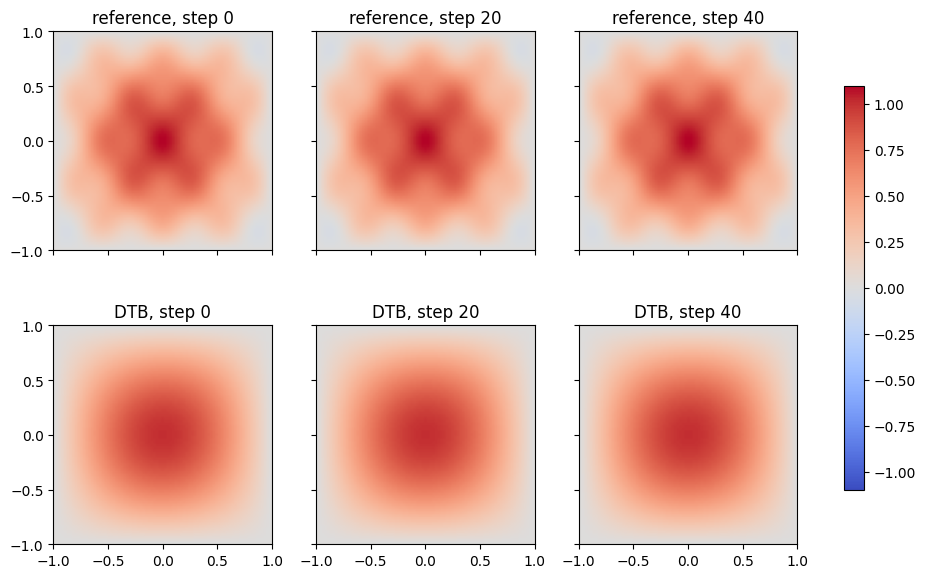

In [11]:
# Reference (top) and DTB (bottom) at the requested diagnostic times.
reference = exact(grid).reshape(81,81).numpy(); limit = np.max(np.abs(reference))
fig, axes = plt.subplots(2, len(snapshots), figsize=(12,7), sharex=True, sharey=True)
for column, (step, field) in enumerate(snapshots.items()):
    for row, (values, label) in enumerate([(reference,'reference'),(field,'DTB')]):
        image = axes[row,column].imshow(values.T, origin='lower', extent=(-1,1,-1,1), cmap='coolwarm', vmin=-limit, vmax=limit)
        axes[row,column].set_title(f'{label}, step {step}')
fig.colorbar(image, ax=axes, shrink=.75); plt.show()

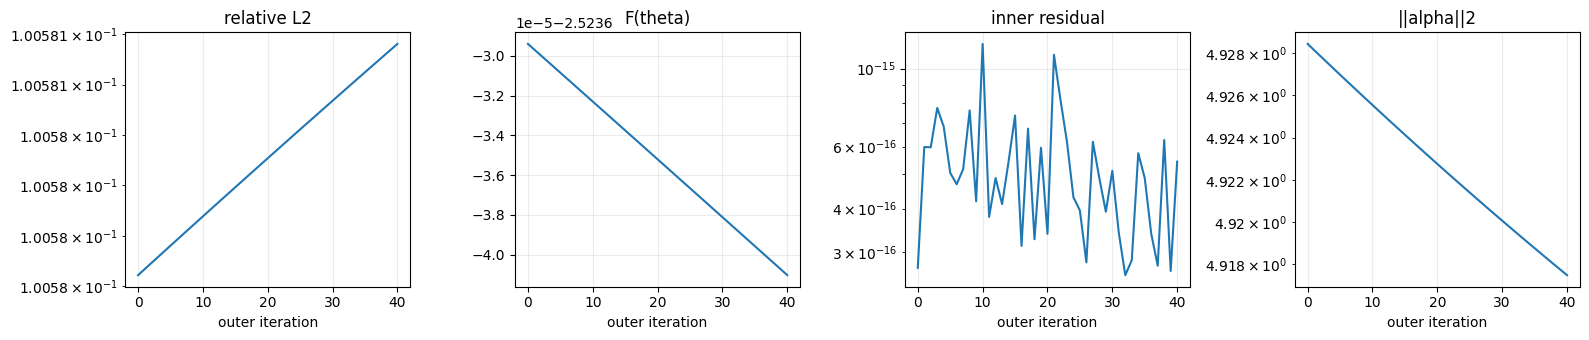

In [12]:
fig, axes = plt.subplots(1,4,figsize=(16,3.5)); steps=[r['step'] for r in history]
series=[('relative_l2','relative L2',True),('F_theta','F(theta)',False),('inner_residual','inner residual',True),('alpha_norm','||alpha||2',True)]
for ax,(key,title,logy) in zip(axes,series):
    ax.plot(steps,[r[key] for r in history]); ax.set(xlabel='outer iteration',title=title); ax.grid(alpha=.25)
    if logy: ax.set_yscale('log')
plt.tight_layout(); plt.show()